# 레이블 없는 데이터를 활용한 사전 훈련 목차
* [Chapter 1 텍스트 생성 모델 평가하기](#chapter1)
* [Chapter 2 LLM 훈련하기](#chapter2)

## Chapter 1 텍스트 생성 모델 평가하기 <a class="anchor" id="chapter1"></a>
1. 텍스트 생성 과정을 간략히 정리한 후 텍스트 생성을 위해 LLM을 준비한다.

2. 생성된 텍스트의 품질을 평가하는 기본적인 방법을 소개한다.

    ![구현 순서](image/05-01-process2.png)

3. GPT를 사용해 텍스트 생성하기
   - LLM을 준비하고 텍스트 생성 과정을 간단하게 복습한다.

      ![구현 순서2](image/05-01-processTxt2.png)

In [1]:
# 깃허브에서 previous_chapters.py 파일을 다운로드합니다.
!wget https://bit.ly/3HlFmc8 -O previous_chapters.py

--2025-10-16 10:54:22--  https://bit.ly/3HlFmc8
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/previous_chapters.py [following]
--2025-10-16 10:54:23--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/previous_chapters.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9905 (9.7K) [text/plain]
Saving to: ‘previous_chapters.py’

previous_chapters.p 100%[===================>]   9.67K  --.-KB/s    in 0s      

2025-10-16 10:54:23 (75.8 MB/s) - ‘previous_chapter

In [4]:
import torch
from previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257, # GPT-2 BPE 토크나이저의 어휘 크기
    "context_length": 256, # 모델 훈련에 필요한 계산 자원을 절감하기 위해 문맥 길이(context_length)를 256 토큰으로 줄인다.
    "emb_dim": 768, 
    "n_heads": 12, # 12개의 어텐션 헤드
    "n_layers": 12, # 12개의 트랜스포머 블록
    "drop_rate": 0.1, # 드롭아웃 확률 - 요즘에는 드롭아웃을 사용하지 않고 LLM을 훈련하는 경우가 많다.
    "qkv_bias": False, # 최신 LLM은 (초기 GPT 모델과 달리) 쿼리, 키, 값 행렬을 위한 nn.Linear 층에서 편향 벡터를 사용하지 않는다.
}

torch.manual_seed(123) # 재현성을 위해 시드 설정
model = GPTModel(GPT_CONFIG_124M) # 모델 초기화
model.eval() # 평가 모드로 전환

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [60]:
import tiktoken
from previous_chapters import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # 배치 차원을 삭제합니다
    return tokenizer.decode(flat.tolist())




In [ ]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

4. 텍스트 생성 손실 계산하기
    - 데이터를 로드하는 방법과 generate_text_simple 함수로 텍스트를 생성하는 방법을 간단히 정리한다.   
    - generate_text_simple이 내부적으로 수행하는 작업니다.
    - 모델이 아직 훈련을 하지 않아 타킷 토큰과 생성된 토큰이 거의 일치하지 않는다.

        ![간단 정리](image/05-01-processTxt4.png)
        

In [6]:
# 두 개의 입력
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

# 두 개의 타깃
#   - 타킷은 한 위치 앞으로 이동한 입력이다
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [7]:
# 입력을 모델에 주입하고 각각 3개의 토큰으로 구성된 로짓 벡터를 계산한다.
with torch.no_grad(): # 평가 모드에서는 그래디언트를 계산하지 않는다.
    logits = model(inputs)
    
probas = torch.softmax(logits, dim=-1) # 로짓을 확률로 변환한다.
# 2: 배치 크기, 3: 시퀀스 길이, 50257: 어휘 크기
print("probas shape:", probas.shape) # (2, 3, 50257)

probas shape: torch.Size([2, 3, 50257])


In [8]:
# softmax 함수로 로짓을 확률로 변환한 후에 이 확률 점수를 텍스트로 다시 변환
token_ids = torch.argmax(probas, dim=-1, keepdim=True) # 가장 높은 확률을 갖는 토큰을 선택
print("생성된 토큰 IDs:\n", token_ids)

# 
print(f"첫 번째 샘플의 타깃: {token_ids_to_text(targets[0], tokenizer)}")
print(f"두 번째 샘플의 출력: {token_ids_to_text(token_ids[1].flatten(), tokenizer)}")



생성된 토큰 IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])
첫 번째 샘플의 타깃:  effort moves you
두 번째 샘플의 출력:  pressuring empoweredfaith


5. 모델 훈련의 목적은 정답 타깃 ID에 해당하는 인덱스의 소프트맥스 확률을 증가시키는 것이다.
    - 다른 토큰에 비해 정답 토큰의 확률을 높여야한다
    - 토큰 ID에 대해 모델이 높은 값을 출력하도록 가중치를 높여야한다.
    - 가중치 업데이트는 심층 신경망 기법인 역전파 과정을 통해 수행된다.
    - 역전파에는 모델의 예측과 실제 출력 사이의 차이를 계산하는 손실함수가 필요하다
    - 손실 함수는 모델의 예측 값과 타깃 값이 얼마나 떨어져있는지를 측정한다.

    ![훈련 목적](image/05-01-target2.png)

6. 두 샘플의 확률 점수에 대한 손실을 계산한다.
    - 모델의 가중치를 업데이트하여 평균 로그 확률이 가능한 0에 가깝게 만드는 것이 목표이다.
    - 일반적인 딥러닝에서는 음의 평균 로그 확률을 0으로 만든다.
       - 평균 로그 확률에 -1을 곱한다.

        ![손실계산](image/05-01-loss2.png)    

7. 크로스 엔트로피(cross-entropy) 손실 함수
    - 딥러닝에서 음수를 양수로 바꾼다.
    - 파이토치에서는 nn.CrossEntropyLoss() 클래스로 제공된다.
    - 두 확률 분포 사이의 차이를 계산한다.
    - 모델이 생성한 토큰 확률이 주어졌을 때 타깃 토큰에 대한 음의 평균 로그 확률과 비슷하다.

8. 혼잡도(perplexity)
    - 혼잡도는 모델이 다음 토큰을 얼마나 잘 예측하는지를 나타내는 지표이다.
    - 혼잡도는 모델의 예측이 얼마나 불확실한지를 나타낸다.
    - 혼잡도가 낮을수록 모델의 예측이 더 확실하다.
    - 혼잡도는 음의 평균 로그 확률의 지수 함수로 정의된다.
    - 혼잡도가 낮을수록 모델의 성능이 좋다.

    

In [10]:
# 손실 계산 1 ~ 3 단계
#   - 로짓  -> 확률 -> 타깃 토큰 확률
text_idx = 0
target_probas_1 =  probas[text_idx, [0, 1, 2], targets[text_idx]]
print("첫 번째 샘플의 타깃 토큰에 대한 초기 확률:", target_probas_1)

text_idx = 1
target_probas_2 =  probas[text_idx, [0, 1, 2], targets[text_idx]]
print("두 번째 샘플의 타깃 토큰에 대한 초기 확률:", target_probas_2)

첫 번째 샘플의 타깃 토큰에 대한 초기 확률: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
두 번째 샘플의 타깃 토큰에 대한 초기 확률: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [11]:
# 손실 계산 4 단계
#   - 로그 확률
# 타깃 토큰에 대한 음의 로그 확률을 계산한다.
#   - 로그 확률은 매우 작은 확률 값을 더 안정적으로 다룰 수 있게 해준다.
#   - 로그 확률은 확률 값이 0에 가까워질수록 더 큰 음수 값을 갖게 된다.
#   - 로그 확률을 최대화하는 것은 확률을 최대화하는 것과 같다.
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print("타깃 토큰에 대한 로그 확률:", log_probas)

타깃 토큰에 대한 로그 확률: tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [13]:
# 손실 계산 5 단계
#   - 평균 로그 확률
avg_log_proba = torch.mean(log_probas)
print("평균 로그 확률:", avg_log_proba)

neg_avg_log_proba = avg_log_proba * -1
print("음의 평균 로그 확률(손실 값):", neg_avg_log_proba)

평균 로그 확률: tensor(-10.7940)
음의 평균 로그 확률(손실 값): tensor(10.7940)


In [14]:
# 로짓과 타깃 텐서의 크기 확인
print("로짓의 크기:", logits.shape)  # (2, 3, 50257) - 배치 크기 2, 시퀀스 길이 3, 어휘 크기 50257
print("타깃의 크기:", targets.shape)  # (2, 3) - 배치 크기 2, 시퀀스 길이 3

로짓의 크기: torch.Size([2, 3, 50257])
타깃의 크기: torch.Size([2, 3])


In [15]:
# 파이토치의 크로스 엔트로피 손실 함수를 위해 처음 두 차원을 결합하여 두 텐서를 펼친다.
logits_flat = logits.flatten(0, 1)
print("펼쳐진 로짓의 크기:", logits_flat.shape)  # (6, 50257) - 배치 크기 * 시퀀스 길이, 어휘 크기

targets_flat = targets.flatten()
print("펼쳐진 타깃의 크기:", targets_flat.shape)  # (6,) - 배치 크기 * 시퀀스 길이

펼쳐진 로짓의 크기: torch.Size([6, 50257])
펼쳐진 타깃의 크기: torch.Size([6])


In [25]:
inputs2 = torch.tensor(
  [
      [[1,1,1,1,1],[2,2,2,2,2],[3,3,3,3,3]], 
      [[4,4,4,4,4],[5,5,5,5,5],[6,6,6,6,6]], 
      [[7,7,7,7,7],[8,8,8,8,8],[9,9,9,9,9]], 
      [[10,10,10,10,10],[11,11,11,11,11],[12,12,12,12,12]], 
      [[13,13,13,13,13],[14,14,14,14,14],[15,15,15,15,15]], 
      [[16,16,16,16,16],[17,17,17,17,17],[18,18,18,18,18]]  
  ]
)

print("inputs2:", inputs2.shape)

inputs3 = inputs2.flatten(0, 1)
print("inputs3:", inputs3)
print("inputs3:", inputs3.shape)

inputs2: torch.Size([6, 3, 5])
inputs3: tensor([[ 1,  1,  1,  1,  1],
        [ 2,  2,  2,  2,  2],
        [ 3,  3,  3,  3,  3],
        [ 4,  4,  4,  4,  4],
        [ 5,  5,  5,  5,  5],
        [ 6,  6,  6,  6,  6],
        [ 7,  7,  7,  7,  7],
        [ 8,  8,  8,  8,  8],
        [ 9,  9,  9,  9,  9],
        [10, 10, 10, 10, 10],
        [11, 11, 11, 11, 11],
        [12, 12, 12, 12, 12],
        [13, 13, 13, 13, 13],
        [14, 14, 14, 14, 14],
        [15, 15, 15, 15, 15],
        [16, 16, 16, 16, 16],
        [17, 17, 17, 17, 17],
        [18, 18, 18, 18, 18]])
inputs3: torch.Size([18, 5])


In [28]:
# 파이토치 크로스 엔트로피 손실 함수 사용
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print("파이토치 크로스 엔트로피 손실 함수 값:", loss)

# 혼잡도 (perplexity) 계산
perplexity = torch.exp(loss)
# 48,725개의 토큰 중에 어떤 것을 사용할 지 불확살하다.
print("혼잡도 (perplexity):", perplexity)

파이토치 크로스 엔트로피 손실 함수 값: tensor(10.7940)
혼잡도 (perplexity): tensor(48725.8203)


9. 훈련 세트와 검증 세트의 손실 계산하기
    - LLM을 훈련하는 데 사용할 훈련 데이터 셋과 검증 데이터 셋을 준비한다.
    - 텍스트 데이터 셋으로 이디스 워튼의 단편 소설 'The Verdict'를 사용한다.
        - 적절한 GPU가 없는 랩탑 컴퓨터에서 몇 분 안에 코드 예제가 실행되어야 합니다.
        - 교육 목적을 위해 훈련이 비교적 빨리 끝나야 합니다(몇 주가 아니라 몇 분 만에).
        - 사용 권리를 위반하지 않으며 깃허브 저장소에 저장할 수 있는 크기의 공개된 텍스트를 사용해야 합니다.
    - 데이터셋을 훈련 세트와 검증 세트로 나눈다.

        ![데이터셋](image/05-01-data2.png)  

In [29]:
file_path = 'the-verdict.txt'
with open(file_path, 'r', encoding='utf-8') as f:
    text_data = f.read()
    
total_characters = len(text_data)
print("총 문자 수:", total_characters)

total_tokens = len(tokenizer.encode(text_data))
print("총 토큰 수:", total_tokens)

총 문자 수: 20479
총 토큰 수: 5145


In [37]:
# 훈련 데이터 셋 90%, 검증 데이터 셋 10%로 분할
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [41]:
from previous_chapters import create_dataloader_v1

# 훈련 세트 비율
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [42]:
# 유효성 검사
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("훈련 데이터 로더에 토큰이 충분하지 않습니다. "
          "`GPT_CONFIG_124M['context_length']`를 낮추거나 "
          "`training_ratio`를 증가시키세요.")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("훈련 데이터 로더에 토큰이 충분하지 않습니다. "
          "`GPT_CONFIG_124M['context_length']`를 낮추거나 "
          "`training_ratio`를 증가시키세요.")

In [43]:
print("훈련 데이터 로더:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\n검증 데이터 로더:")
for x, y in val_loader:
    print(x.shape, y.shape)

훈련 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

검증 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])


In [44]:
# 훈련 데이터 로더와 검증 데이터 로더가 반환한 배치로 크로스 엔트로피 손실을 계산하는 유틸
def calc_loss_batch(input_batch, target_batch, model, device):
    # 데이터를 저장된 장치로 전송
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    
    logits = model(input_batch)
    
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),  # (배치 크기 * 시퀀스 길이, 어휘 크기)
        target_batch.flatten()  # (배치 크기 * 시퀀스 길이)
    )
    return loss

In [45]:
# 데이터 로더가 반환하는 모드 배치에 대한 손실 계산
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(data_loader) # num_batches가 지정되지 않으면 전체 배치 수를 사용
    else:
        num_batches = min(num_batches, len(data_loader)) # num_batches가 데이터 로더의 배치 수보다 크면 데이터 로더의 배치 수로 제한
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item() # 손실 값을 파이썬 숫자로 변환하여 누적

    return total_loss / num_batches # 평균 손실 반환


In [48]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("사용 장치:", device)

# 모델이 아직 훈련되지 않았기 때문에 손실 값이 비교적 높다.
model.to(device) # 모델을 지정된 장치로 전송
with torch.no_grad(): # 평가 모드에서는 그래디언트를 계산하지 않는다.
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
    print("훈련 손실:", train_loss)
    print("검증 손실:", val_loss)

사용 장치: cuda
훈련 손실: 10.987583372328016
검증 손실: 10.98110580444336


## Chapter 2 LLM 훈련하기 <a class="anchor" id="chapter2"></a>
1. GPTModel LLM을 사전 훈련 코드를 간결하고 가독성 있게 유지하기 위해 훈련 루프를 만든다.

    ![훈련 루프](image/05-02-training3.png)

In [63]:
# LLM 사전 훈련을 위한 함수
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # 손실과 지금까지 처리한 토큰 수를 추적하기 위해 리스트를 초기화합니다.
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # 메인 훈련 루프를 시작합니다.
    for epoch in range(num_epochs):
        model.train()  # 모델을 훈련 모드로 설정합니다.

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # 이전 배치 반복에서 얻은 손실의 그레이디언트를 초기화합니다.
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # 손실의 그레이디언트를 계산합니다.
            optimizer.step() # 손실의 그레이디언트를 사용하여 모델 가중치를 업데이트합니다.
            tokens_seen += input_batch.numel()
            global_step += 1

            # 추가적인 평가 단계
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"에포크 {epoch+1} (Step {global_step:06d}): "
                      f"훈련 손실 {train_loss:.3f}, 검증 손실 {val_loss:.3f}")

        # 각 에포크 후에 샘플 텍스트를 출력합니다.
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # 간결한 출력 포맷을 위해
    model.train()

2. AdamW는 심층 신경망을 훈련하는데 사용되는 인기 있는 옵티마이져다
    - Adam 옵티마이져의 변형으로, 가중치 감쇠(weight decay)를 적용하여 과적합을 방지한다.
    - Transformer 기반 모델 훈련에 자주 사용된다.
    - 파이토치에서는 torch.optim.AdamW 클래스로 제공된다.

In [ ]:
# AdamW 옵티마이저를 사용하여 GPTModel 개체를 10 에포크 동안 훈련
torch.manual_seed(123) # 재현성을 위해 시드 설정
model = GPTModel(GPT_CONFIG_124M) # 모델 초기화
model.to(device)

# 옵티마이저 설정
optimizer = torch.optim.AdamW(model.parameters(), # 모델에서 훈련 가능한 모든 가중치 반환
                              lr=0.0004, # 학습률 설정
                              weight_decay=0.1) # 가중치 감쇠 설정
num_epochs = 10
train_losses, val_losses, track_token_seen = train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    eval_freq=5, # 5 에포크마다 손실 평가
    eval_iter=5, # 각 평가에서 5개의 배치 사용
    start_context="Every effort moves you",
    tokenizer=tokenizer
)


에포크 1 (Step 000000): 훈련 손실 9.823, 검증 손실 9.932
에포크 1 (Step 000005): 훈련 손실 8.067, 검증 손실 8.339
Every effort moves you,,,,,,,,,,,,.                                     
에포크 2 (Step 000010): 훈련 손실 6.624, 검증 손실 7.051
에포크 2 (Step 000015): 훈련 손실 6.049, 검증 손실 6.601
Every effort moves you, and,, and,,,,,,, and,.                                   
에포크 3 (Step 000020): 훈련 손실 5.589, 검증 손실 6.480
에포크 3 (Step 000025): 훈련 손실 5.527, 검증 손실 6.400
Every effort moves you, and, and the to the of the to the to the of the of the of the to the of the Stroud, and, and the of the of the to the.             
에포크 4 (Step 000030): 훈련 손실 5.150, 검증 손실 6.342
에포크 4 (Step 000035): 훈련 손실 5.001, 검증 손실 6.407
Every effort moves you, and a. Gisburn. I had the picture. Gisburn. I had the of the of the, and a.. I had been the of the of the of the. I had been. I had been. I had
에포크 5 (Step 000040): 훈련 손실 4.374, 검증 손실 6.241
Every effort moves you, I had the picture--as of the picture--as I had been the of the picture--as of the f

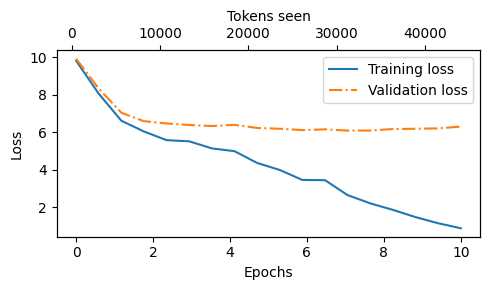

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # 에포크에 대한 훈련 손실과 검증 손실의 그래프를 그립니다.
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # 처리한 토큰 수에 대한 두 번째 x 축을 만듭니다.
    ax2 = ax1.twiny()  # y 축을 공유하는 두 번째 x 축을 만듭니다.
    ax2.plot(tokens_seen, train_losses, alpha=0)  # 눈금을 정렬하기 위해 투명한 그래프를 만듭니다.
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))

plot_losses(epochs_tensor, track_token_seen, train_losses, val_losses)

3. 그래프 분석
    - 훈련 손실과 검증 손실은 모두 첫 번째 에포크 부터 향상되기 시작한다.
    - 위 결과를 보면 모델이 처음에는 이해할 수 없는 단어를 생성하지만 마지막으로 갈수록 문법적으로 어느 정도 정확한 문장을 생성합니다.
    - 두 번째 에포크를 지나면서 두 손실이 벌어지기 시작한다.
    - 검증 손실이, 훈련 손실보다 크다는 것은 모델이 훈련 데이터에 과적합되고 있음을 나타낸다.
        - 매우 작은 훈련 세트를 사용하고 모델을 여러 에포크에서 훈련하고 있기 때문에 과대적합이 일어납니다
        - "The Verdict" 텍스트 팩에서 모델이 생성한 텍스트 "quite insensible to the irony"와 같은 구문을 그대로 기억하고 있음을 알 수 있다.
    - 여기서는 교육적인 목적을 위해 LLM을 훈련합니다. 모델이 일관된 텍스트를 생성하는 방법을 학습할 수 있는지 확인하는 것이 주요 목적입니다.
    - 대량의 고가 하드웨어에서 몇 주 또는 몇 달 동안 이런 모델을 훈련하는 대신에 나중에 사전 훈련된 가중치를 로드하여 사용하겠습니다.